Stress level prediction

EDA

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [8]:
df = pd.read_csv('Data/stress_detection_data.csv')
df.head()

,Age,Gender,Occupation,Marital_Status,Sleep_Duration,Sleep_Quality,Wake_Up_Time,Bed_Time,Physical_Activity,Screen_Time,...,Smoking_Habit,Work_Hours,Travel_Time,Social_Interactions,Meditation_Practice,Exercise_Type,Blood_Pressure,Cholesterol_Level,Blood_Sugar_Level,Stress_Detection
0,30,Male,Software Engineer,Single,7.0,4.0,7:00 AM,10:00 PM,2.0,4.0,...,No,8,1.0,5,Yes,Cardio,120,180,90,Low
1,35,Female,Marketing Manager,Married,6.0,3.0,6:00 AM,11:00 PM,1.0,3.0,...,No,9,2.0,3,No,Yoga,110,160,80,Medium
2,40,Male,Data Scientist,Divorced,7.0,4.0,7:00 AM,10:00 PM,2.0,4.0,...,No,8,1.0,5,Yes,Strength Training,130,200,100,High
3,35,Male,Software Engineer,Single,7.0,4.0,7:00 AM,10:00 PM,2.0,4.0,...,No,8,1.0,5,Yes,Cardio,120,180,90,Low
4,29,Female,Teacher,Single,8.0,5.0,6:30 AM,10:30 PM,3.0,2.0,...,No,7,1.0,4,Yes,Yoga,110,180,90,Low


In [9]:
df.shape

(773, 22)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 773 entries, 0 to 772
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  773 non-null    int64  
 1   Gender               773 non-null    object 
 2   Occupation           773 non-null    object 
 3   Marital_Status       773 non-null    object 
 4   Sleep_Duration       773 non-null    float64
 5   Sleep_Quality        773 non-null    float64
 6   Wake_Up_Time         773 non-null    object 
 7   Bed_Time             773 non-null    object 
 8   Physical_Activity    773 non-null    float64
 9   Screen_Time          773 non-null    float64
 10  Caffeine_Intake      773 non-null    int64  
 11  Alcohol_Intake       773 non-null    int64  
 12  Smoking_Habit        773 non-null    object 
 13  Work_Hours           773 non-null    int64  
 14  Travel_Time          773 non-null    float64
 15  Social_Interactions  773 non-null    int

In [11]:
df.isnull().sum()

Age                    0
Gender                 0
Occupation             0
Marital_Status         0
Sleep_Duration         0
Sleep_Quality          0
Wake_Up_Time           0
Bed_Time               0
Physical_Activity      0
Screen_Time            0
Caffeine_Intake        0
Alcohol_Intake         0
Smoking_Habit          0
Work_Hours             0
Travel_Time            0
Social_Interactions    0
Meditation_Practice    0
Exercise_Type          0
Blood_Pressure         0
Cholesterol_Level      0
Blood_Sugar_Level      0
Stress_Detection       0
dtype: int64

In [12]:
df.describe()


,Age,Sleep_Duration,Sleep_Quality,Physical_Activity,Screen_Time,Caffeine_Intake,Alcohol_Intake,Work_Hours,Travel_Time,Social_Interactions,Blood_Pressure,Cholesterol_Level,Blood_Sugar_Level
count,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000
mean,38.887451,6.338422,3.848124,2.979301,4.105433,1.818887,0.888745,8.258732,2.858344,3.196636,137.943079,220.834411,111.765847
std,7.686642,0.733584,0.545459,0.797234,0.812513,0.838396,0.673741,1.064168,1.083758,0.856332,13.122060,19.322622,12.533097
min,18.000000,3.500000,2.000000,1.000000,2.000000,0.000000,0.000000,6.000000,0.500000,1.000000,110.000000,150.000000,80.000000
25%,33.000000,6.000000,3.600000,2.000000,4.000000,1.000000,0.000000,8.000000,2.000000,3.000000,130.000000,210.000000,105.000000
50%,39.000000,6.300000,3.900000,3.000000,4.000000,2.000000,1.000000,8.000000,3.000000,3.000000,140.000000,220.000000,115.000000
75%,45.000000,7.000000,4.000000,4.000000,5.000000,2.000000,1.000000,9.000000,4.000000,4.000000,150.000000,230.000000,120.000000
max,60.000000,8.000000,5.000000,5.000000,8.000000,4.000000,2.000000,14.000000,5.000000,5.000000,170.000000,290.000000,150.000000


In [13]:
num_cols = df.select_dtypes(include=['number']).columns
cat_cols = df.select_dtypes(include=['object']).columns


In [14]:
num_cols

Index(['Age', 'Sleep_Duration', 'Sleep_Quality', 'Physical_Activity',
       'Screen_Time', 'Caffeine_Intake', 'Alcohol_Intake', 'Work_Hours',
       'Travel_Time', 'Social_Interactions', 'Blood_Pressure',
       'Cholesterol_Level', 'Blood_Sugar_Level'],
      dtype='object')

In [15]:
cat_cols

Index(['Gender', 'Occupation', 'Marital_Status', 'Wake_Up_Time', 'Bed_Time',
       'Smoking_Habit', 'Meditation_Practice', 'Exercise_Type',
       'Stress_Detection'],
      dtype='object')

In [16]:
for col in cat_cols:
    print(f"{col} → {df[col].nunique()} ")


Gender → 2 
Occupation → 169 
Marital_Status → 3 
Wake_Up_Time → 10 
Bed_Time → 19 
Smoking_Habit → 2 
Meditation_Practice → 2 
Exercise_Type → 7 
Stress_Detection → 3 


In [17]:
df['Exercise_Type'].unique()

array(['Cardio', 'Yoga', 'Strength Training', 'Aerobics', 'Walking',
       'Pilates', 'Meditation'], dtype=object)

In [18]:
df['Marital_Status'].unique()

array(['Single', 'Married', 'Divorced'], dtype=object)

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df.columns

Index(['Age', 'Gender', 'Occupation', 'Marital_Status', 'Sleep_Duration',
       'Sleep_Quality', 'Wake_Up_Time', 'Bed_Time', 'Physical_Activity',
       'Screen_Time', 'Caffeine_Intake', 'Alcohol_Intake', 'Smoking_Habit',
       'Work_Hours', 'Travel_Time', 'Social_Interactions',
       'Meditation_Practice', 'Exercise_Type', 'Blood_Pressure',
       'Cholesterol_Level', 'Blood_Sugar_Level', 'Stress_Detection'],
      dtype='object')

In [21]:
import re

def extract_time_float(x):
    nums = list(map(int, re.findall(r'\d+', x)))
    if len(nums) == 2:        # hour:minute
        return nums[0] + nums[1] / 60
    return float(nums[0])    # only hour

df['Wake_Up_Hour'] = df['Wake_Up_Time'].apply(extract_time_float)
df['Bed_Time_Hour'] = df['Bed_Time'].apply(extract_time_float)


In [22]:
df.head()

,Age,Gender,Occupation,Marital_Status,Sleep_Duration,Sleep_Quality,Wake_Up_Time,Bed_Time,Physical_Activity,Screen_Time,...,Travel_Time,Social_Interactions,Meditation_Practice,Exercise_Type,Blood_Pressure,Cholesterol_Level,Blood_Sugar_Level,Stress_Detection,Wake_Up_Hour,Bed_Time_Hour
0,30,Male,Software Engineer,Single,7.0,4.0,7:00 AM,10:00 PM,2.0,4.0,...,1.0,5,Yes,Cardio,120,180,90,Low,7.0,10.0
1,35,Female,Marketing Manager,Married,6.0,3.0,6:00 AM,11:00 PM,1.0,3.0,...,2.0,3,No,Yoga,110,160,80,Medium,6.0,11.0
2,40,Male,Data Scientist,Divorced,7.0,4.0,7:00 AM,10:00 PM,2.0,4.0,...,1.0,5,Yes,Strength Training,130,200,100,High,7.0,10.0
3,35,Male,Software Engineer,Single,7.0,4.0,7:00 AM,10:00 PM,2.0,4.0,...,1.0,5,Yes,Cardio,120,180,90,Low,7.0,10.0
4,29,Female,Teacher,Single,8.0,5.0,6:30 AM,10:30 PM,3.0,2.0,...,1.0,4,Yes,Yoga,110,180,90,Low,6.5,10.5


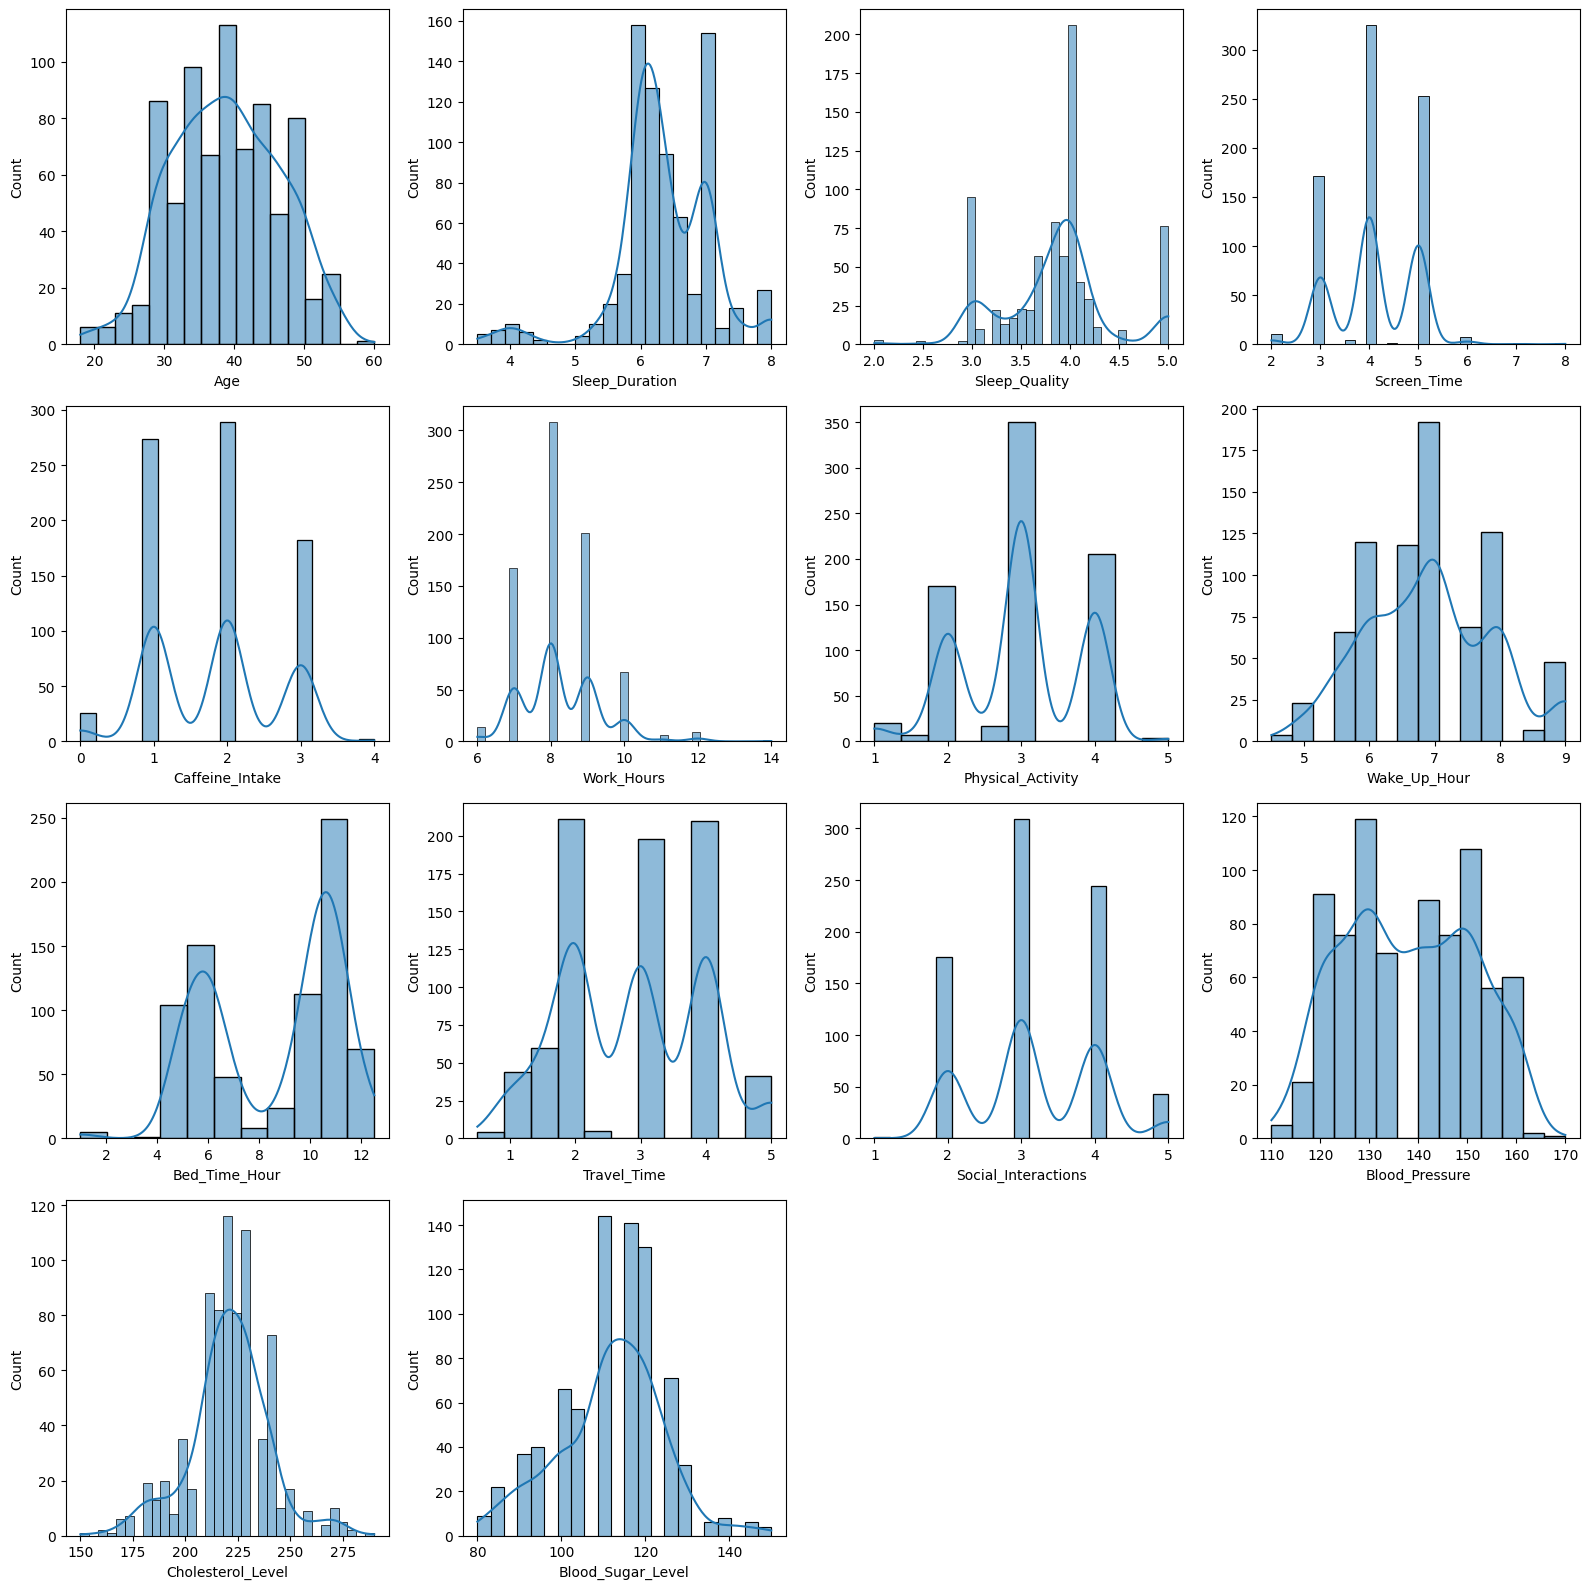

In [23]:
plt.figure(figsize=(16,16))
def plotting(var,num):
    plt.subplot(4,4,num)
    sns.histplot(df[var],kde = True)

plotting('Age',1)
plotting('Sleep_Duration',2)
plotting('Sleep_Quality',3)
plotting('Screen_Time',4)
plotting('Caffeine_Intake',5)
plotting('Work_Hours',6)
plotting('Physical_Activity',7)
plotting('Wake_Up_Hour',8)
plotting('Bed_Time_Hour',9)
plotting('Travel_Time',10)
plotting('Social_Interactions',11)
plotting('Blood_Pressure',12)
plotting('Cholesterol_Level',13)
plotting('Blood_Sugar_Level',14)

plt.tight_layout()

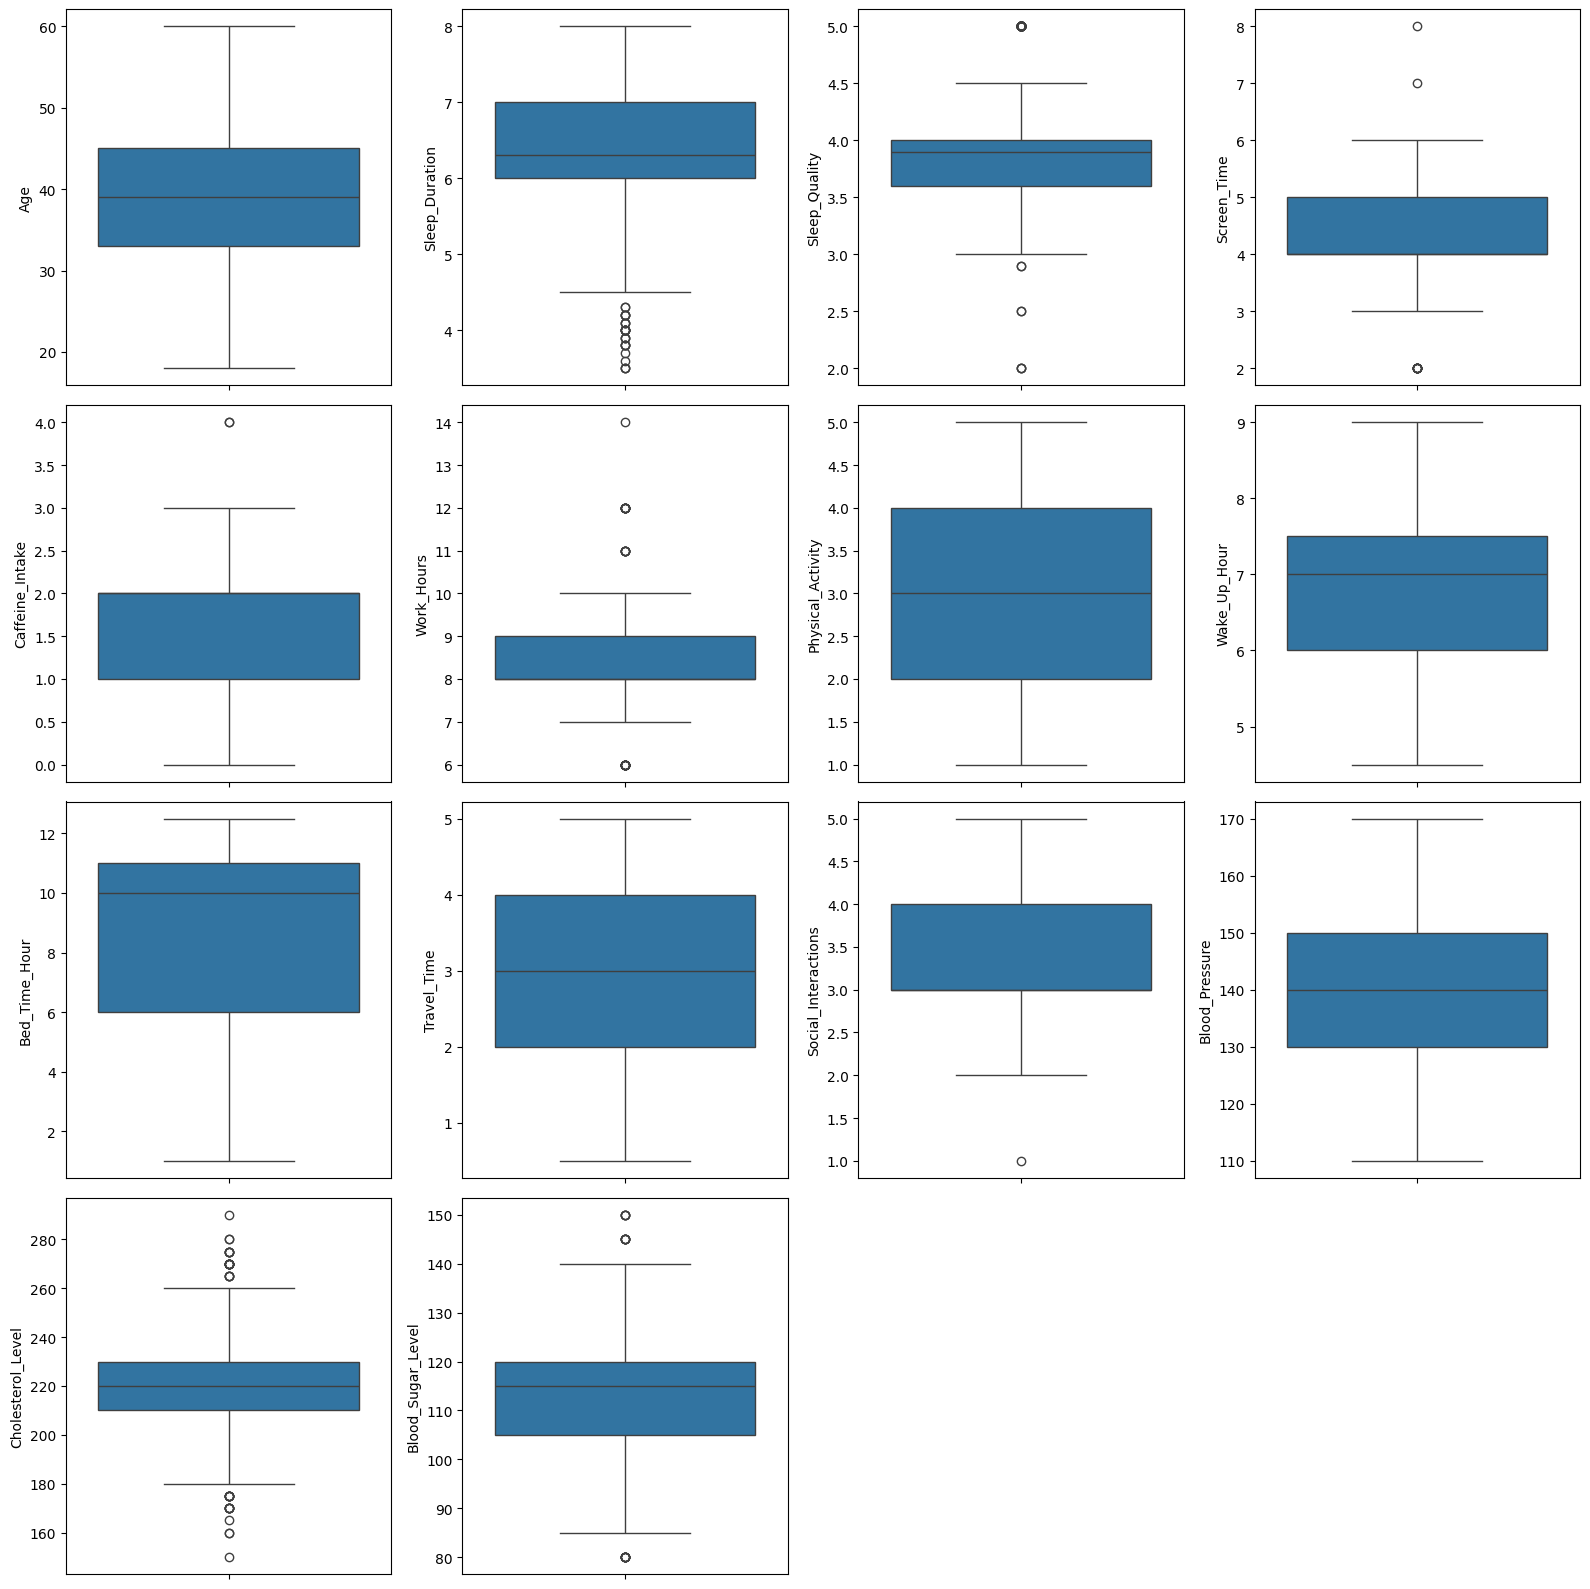

In [24]:
plt.figure(figsize=(16,16))
def plotting(var,num):
    plt.subplot(4,4,num)
    sns.boxplot(df[var])

plotting('Age',1)
plotting('Sleep_Duration',2)
plotting('Sleep_Quality',3)
plotting('Screen_Time',4)
plotting('Caffeine_Intake',5)
plotting('Work_Hours',6)
plotting('Physical_Activity',7)
plotting('Wake_Up_Hour',8)
plotting('Bed_Time_Hour',9)
plotting('Travel_Time',10)
plotting('Social_Interactions',11)
plotting('Blood_Pressure',12)
plotting('Cholesterol_Level',13)
plotting('Blood_Sugar_Level',14)

plt.tight_layout()

In [25]:
df.columns

Index(['Age', 'Gender', 'Occupation', 'Marital_Status', 'Sleep_Duration',
       'Sleep_Quality', 'Wake_Up_Time', 'Bed_Time', 'Physical_Activity',
       'Screen_Time', 'Caffeine_Intake', 'Alcohol_Intake', 'Smoking_Habit',
       'Work_Hours', 'Travel_Time', 'Social_Interactions',
       'Meditation_Practice', 'Exercise_Type', 'Blood_Pressure',
       'Cholesterol_Level', 'Blood_Sugar_Level', 'Stress_Detection',
       'Wake_Up_Hour', 'Bed_Time_Hour'],
      dtype='object')

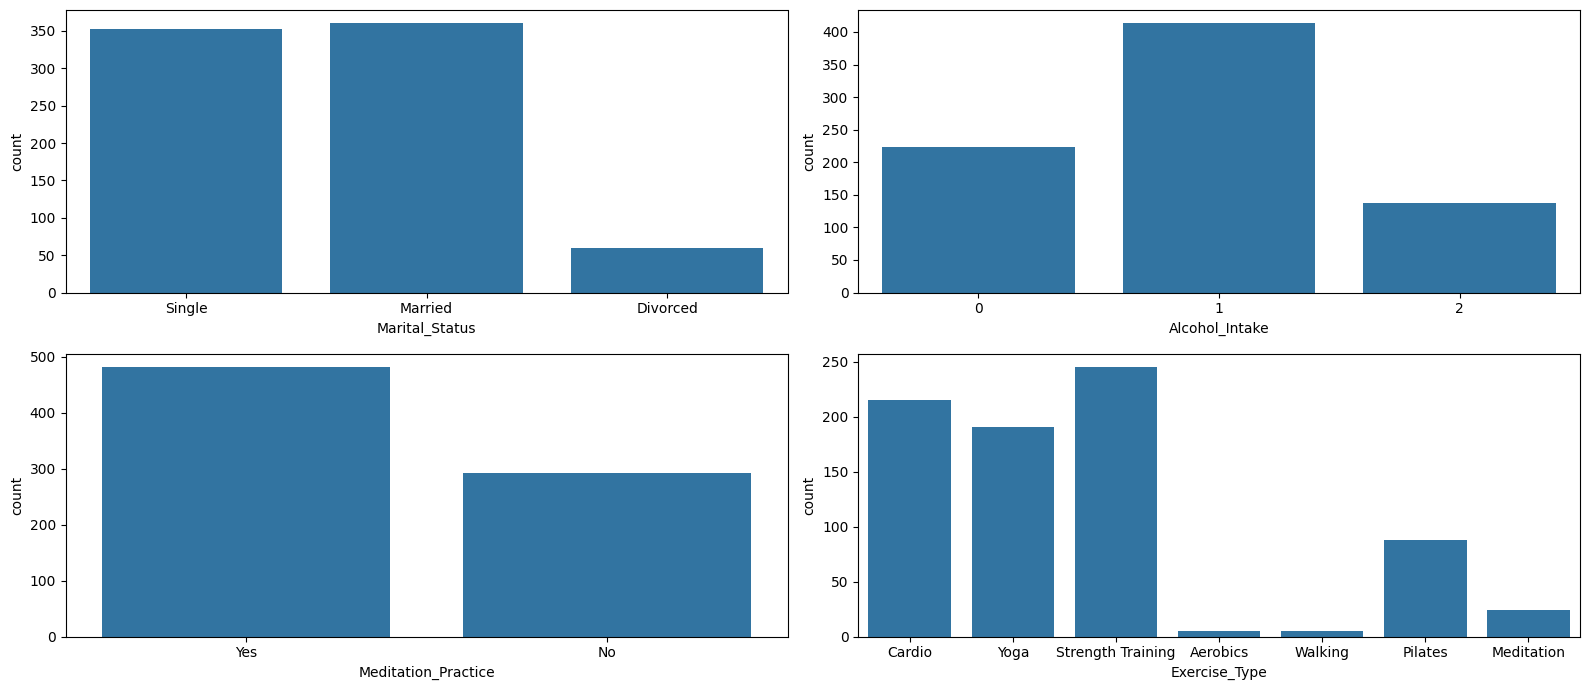

In [26]:
plt.figure(figsize=(16,7))
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.countplot( x=df[var],data=df )

plotting('Marital_Status',1)
plotting('Alcohol_Intake',2)
plotting('Meditation_Practice',3)
plotting('Exercise_Type',4)

plt.tight_layout()

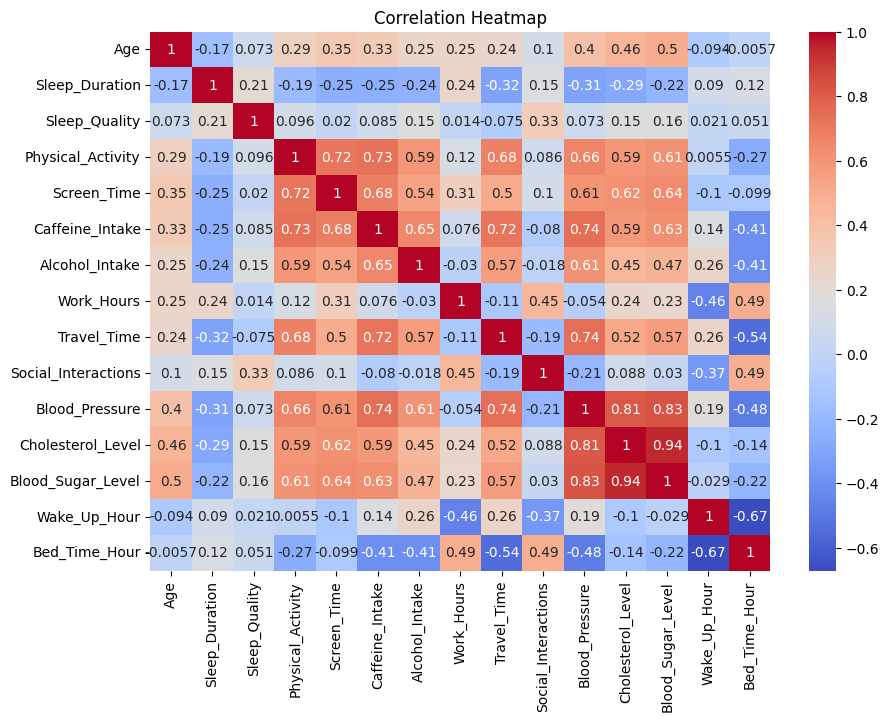

In [27]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

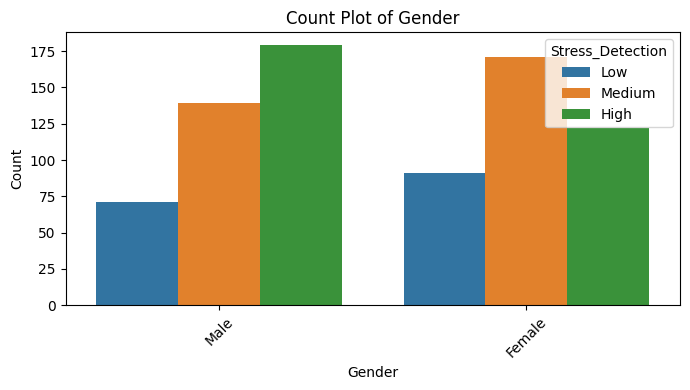

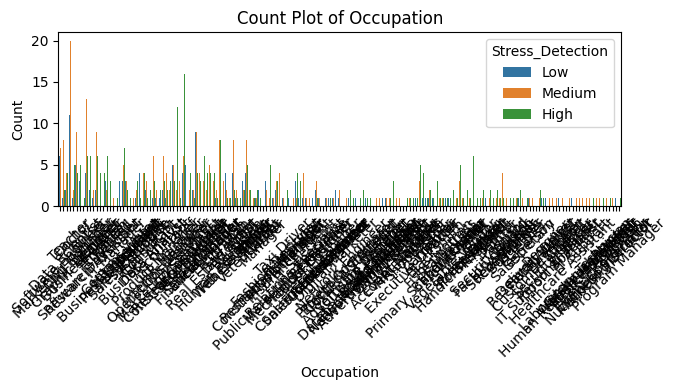

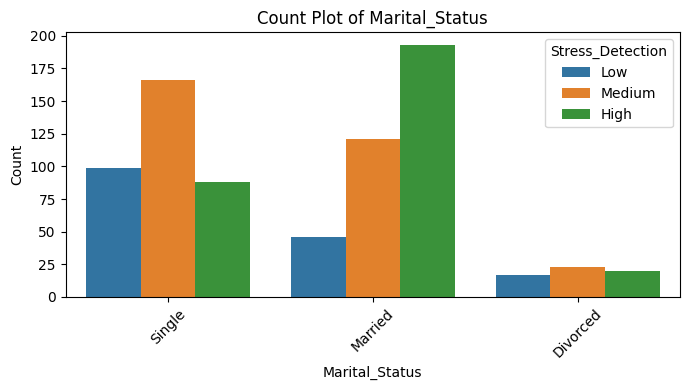

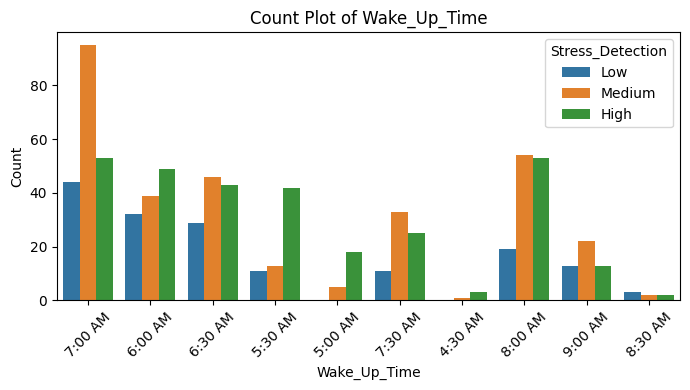

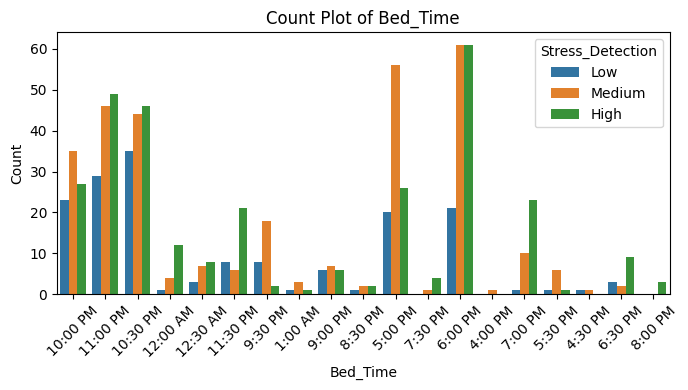

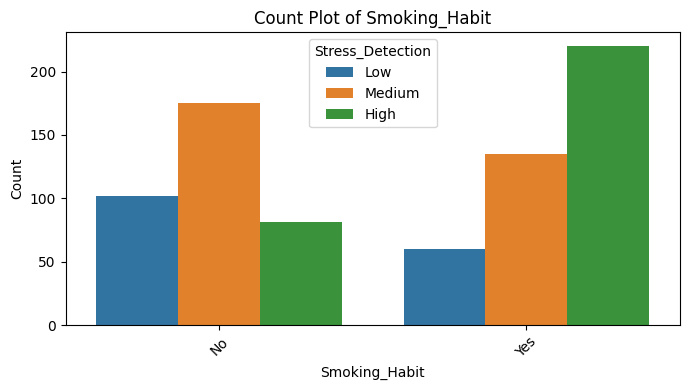

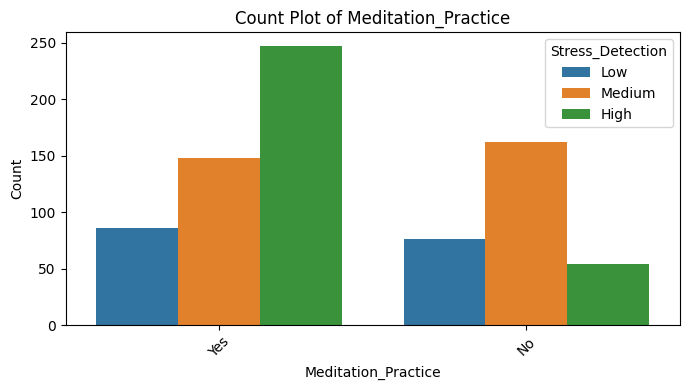

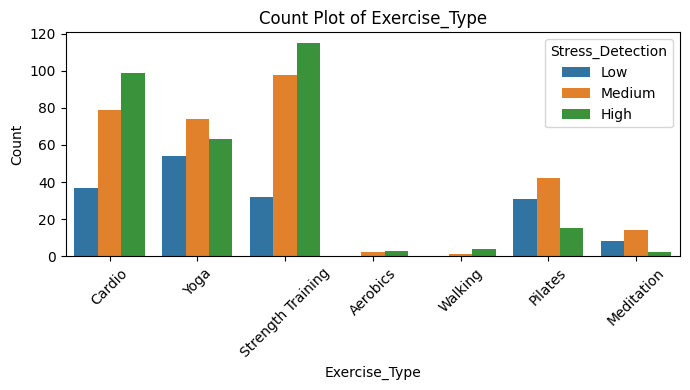

C:\Users\DELL\AppData\Local\Temp\ipykernel_22996\2162023351.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


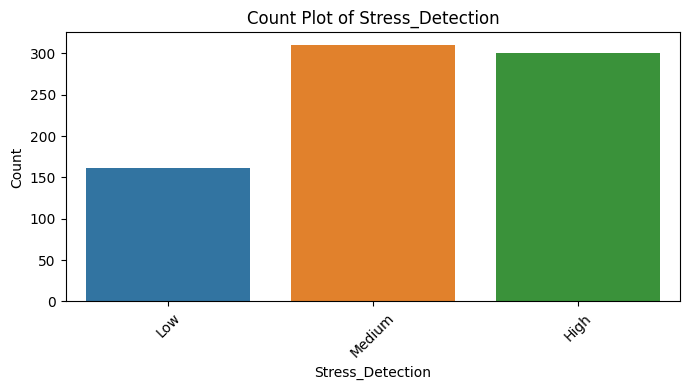

In [28]:
for col in cat_cols:
    plt.figure(figsize=(7, 4))
    
    # use hue only when target exists and column is not target
    if 'Stress_Detection' in df.columns and col != 'Stress_Detection':
        sns.countplot(
            x=df[col],
            hue=df['Stress_Detection'],
            palette='tab10'
        )
        plt.legend(title='Stress_Detection')
    else:
        sns.countplot(
            x=df[col],
            palette='tab10'
        )
    
    plt.title(f"Count Plot of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [29]:
df.columns

Index(['Age', 'Gender', 'Occupation', 'Marital_Status', 'Sleep_Duration',
       'Sleep_Quality', 'Wake_Up_Time', 'Bed_Time', 'Physical_Activity',
       'Screen_Time', 'Caffeine_Intake', 'Alcohol_Intake', 'Smoking_Habit',
       'Work_Hours', 'Travel_Time', 'Social_Interactions',
       'Meditation_Practice', 'Exercise_Type', 'Blood_Pressure',
       'Cholesterol_Level', 'Blood_Sugar_Level', 'Stress_Detection',
       'Wake_Up_Hour', 'Bed_Time_Hour'],
      dtype='object')

In [30]:
df["Smoking_Habit"] = df["Smoking_Habit"].map({
    "No": 0,
    "Yes": 1
})

In [31]:
df["Meditation_Practice"] = df["Meditation_Practice"].map({
    "No": 0,
    "Yes": 1
})

In [32]:
df["Gender"] = df["Gender"].map({
    "Male": 0,
    "Female": 1
})

In [33]:
df["Stress_Detection"] = df["Stress_Detection"].map({
    "Low":0, "Medium": 1, "High": 2
})

In [34]:
occupation_freq = df["Occupation"].value_counts()

df["Occupation_Freq"] = df["Occupation"].map(occupation_freq)

In [35]:
from sklearn.preprocessing import OneHotEncoder
df = pd.get_dummies(
    df,
    columns=[
        "Exercise_Type",
        "Marital_Status"
    ],
    #dtype=int,
    drop_first=True
)

In [36]:
bool_cols = df.select_dtypes(include='bool').columns

df[bool_cols] = df[bool_cols].astype(int)

In [37]:
df.head()

,Age,Gender,Occupation,Sleep_Duration,Sleep_Quality,Wake_Up_Time,Bed_Time,Physical_Activity,Screen_Time,Caffeine_Intake,...,Bed_Time_Hour,Occupation_Freq,Exercise_Type_Cardio,Exercise_Type_Meditation,Exercise_Type_Pilates,Exercise_Type_Strength Training,Exercise_Type_Walking,Exercise_Type_Yoga,Marital_Status_Married,Marital_Status_Single
0,30,0,Software Engineer,7.0,4.0,7:00 AM,10:00 PM,2.0,4.0,1,...,10.0,16,1,0,0,0,0,0,0,1
1,35,1,Marketing Manager,6.0,3.0,6:00 AM,11:00 PM,1.0,3.0,0,...,11.0,11,0,0,0,0,0,1,1,0
2,40,0,Data Scientist,7.0,4.0,7:00 AM,10:00 PM,2.0,4.0,1,...,10.0,10,0,0,0,1,0,0,0,0
3,35,0,Software Engineer,7.0,4.0,7:00 AM,10:00 PM,2.0,4.0,1,...,10.0,16,1,0,0,0,0,0,0,1
4,29,1,Teacher,8.0,5.0,6:30 AM,10:30 PM,3.0,2.0,1,...,10.5,37,0,0,0,0,0,1,0,1


 FEATURE ENGINEERING

In [38]:
# 1. Health Risk Score
# Combines major health indicators
df["Health_Risk_Score"] = (
    df["Blood_Pressure"] +
    df["Blood_Sugar_Level"] +
    df["Cholesterol_Level"]
)

# 2. Lifestyle Risk Score
# Combines unhealthy lifestyle habits
df["Lifestyle_Risk_Score"] = (
    df["Caffeine_Intake"] +
    df["Alcohol_Intake"] +
    df["Smoking_Habit"]
)

# 3. Work-Life Balance
# Represents total work burden
df["Work_Life_Balance"] = (
    df["Work_Hours"] +
    df["Travel_Time"]
)

# 4. Stress Exposure
# Total exposure to stress-inducing activities
df["Stress_Exposure"] = (
    df["Work_Hours"] +
    df["Travel_Time"] +
    df["Screen_Time"]
)

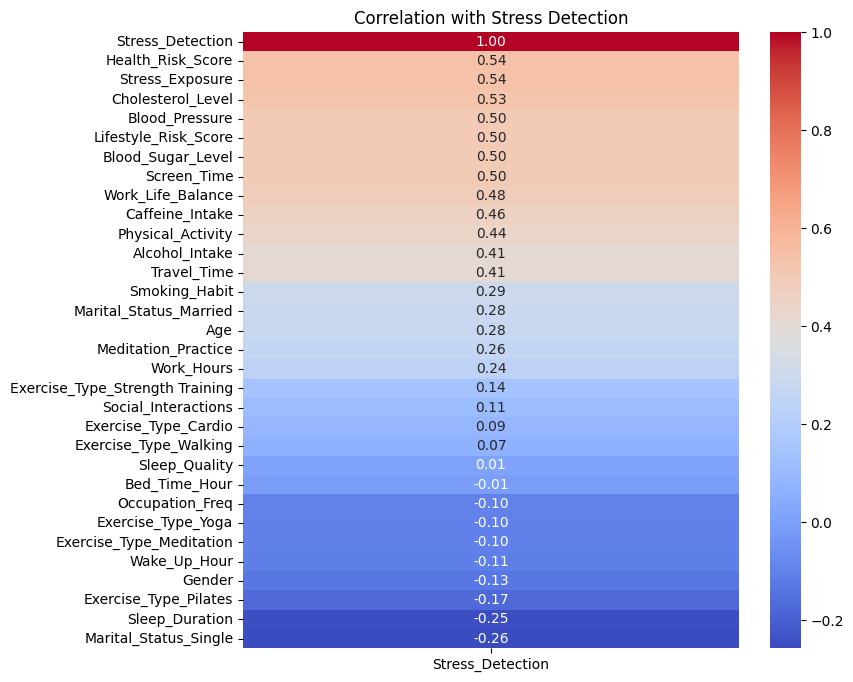

In [39]:
corr_target = (
    df.corr(numeric_only=True)["Stress_Detection"]
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,8))

sns.heatmap(
    corr_target.to_frame(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation with Stress Detection")
plt.show()

In [40]:
df.columns

Index(['Age', 'Gender', 'Occupation', 'Sleep_Duration', 'Sleep_Quality',
       'Wake_Up_Time', 'Bed_Time', 'Physical_Activity', 'Screen_Time',
       'Caffeine_Intake', 'Alcohol_Intake', 'Smoking_Habit', 'Work_Hours',
       'Travel_Time', 'Social_Interactions', 'Meditation_Practice',
       'Blood_Pressure', 'Cholesterol_Level', 'Blood_Sugar_Level',
       'Stress_Detection', 'Wake_Up_Hour', 'Bed_Time_Hour', 'Occupation_Freq',
       'Exercise_Type_Cardio', 'Exercise_Type_Meditation',
       'Exercise_Type_Pilates', 'Exercise_Type_Strength Training',
       'Exercise_Type_Walking', 'Exercise_Type_Yoga', 'Marital_Status_Married',
       'Marital_Status_Single', 'Health_Risk_Score', 'Lifestyle_Risk_Score',
       'Work_Life_Balance', 'Stress_Exposure'],
      dtype='object')

In [41]:
selected_features = [
    'Age',
    'Sleep_Duration',
    'Physical_Activity',
    'Screen_Time',
    'Caffeine_Intake',
    'Alcohol_Intake',
    'Smoking_Habit',
    'Work_Hours',
    'Travel_Time',
    'Social_Interactions',
    'Meditation_Practice',
    'Blood_Pressure',
    'Blood_Sugar_Level',
    'Cholesterol_Level',
    'Marital_Status_Married',
    'Health_Risk_Score',
    'Lifestyle_Risk_Score',
    'Work_Life_Balance',
    'Stress_Exposure',
    'Stress_Detection'   # Target column
]

# New DataFrame
data = df[selected_features]

# Check result
print(data.shape)

(773, 20)


In [42]:
data.head()

,Age,Sleep_Duration,Physical_Activity,Screen_Time,Caffeine_Intake,Alcohol_Intake,Smoking_Habit,Work_Hours,Travel_Time,Social_Interactions,Meditation_Practice,Blood_Pressure,Blood_Sugar_Level,Cholesterol_Level,Marital_Status_Married,Health_Risk_Score,Lifestyle_Risk_Score,Work_Life_Balance,Stress_Exposure,Stress_Detection
0,30,7.0,2.0,4.0,1,0,0,8,1.0,5,1,120,90,180,0,390,1,9.0,13.0,0
1,35,6.0,1.0,3.0,0,1,0,9,2.0,3,0,110,80,160,1,350,1,11.0,14.0,1
2,40,7.0,2.0,4.0,1,0,0,8,1.0,5,1,130,100,200,0,430,1,9.0,13.0,2
3,35,7.0,2.0,4.0,1,0,0,8,1.0,5,1,120,90,180,0,390,1,9.0,13.0,0
4,29,8.0,3.0,2.0,1,0,0,7,1.0,4,1,110,90,180,0,380,1,8.0,10.0,0


In [43]:
corr = data.corr(numeric_only=True)

corr_target = corr["Stress_Detection"].sort_values(
    ascending=False
)

print(corr_target)

Stress_Detection          1.000000
Health_Risk_Score         0.538916
Stress_Exposure           0.538682
Cholesterol_Level         0.532572
Blood_Pressure            0.502711
Lifestyle_Risk_Score      0.502643
Blood_Sugar_Level         0.498705
Screen_Time               0.495994
Work_Life_Balance         0.481582
Caffeine_Intake           0.463924
Physical_Activity         0.438701
Alcohol_Intake            0.407026
Travel_Time               0.406520
Smoking_Habit             0.294250
Marital_Status_Married    0.283426
Age                       0.275103
Meditation_Practice       0.264109
Work_Hours                0.235995
Social_Interactions       0.109784
Sleep_Duration           -0.249053
Name: Stress_Detection, dtype: float64


In [44]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 773 entries, 0 to 772
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     773 non-null    int64  
 1   Sleep_Duration          773 non-null    float64
 2   Physical_Activity       773 non-null    float64
 3   Screen_Time             773 non-null    float64
 4   Caffeine_Intake         773 non-null    int64  
 5   Alcohol_Intake          773 non-null    int64  
 6   Smoking_Habit           773 non-null    int64  
 7   Work_Hours              773 non-null    int64  
 8   Travel_Time             773 non-null    float64
 9   Social_Interactions     773 non-null    int64  
 10  Meditation_Practice     773 non-null    int64  
 11  Blood_Pressure          773 non-null    int64  
 12  Blood_Sugar_Level       773 non-null    int64  
 13  Cholesterol_Level       773 non-null    int64  
 14  Marital_Status_Married  773 non-null    in

In [45]:
X = data.drop("Stress_Detection", axis=1)
y = data["Stress_Detection"]

In [46]:
X.shape

(773, 19)

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [49]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [50]:
models = {

    "Logistic Regression":
    LogisticRegression(max_iter=1000),

    "KNN":
    KNeighborsClassifier(n_neighbors=5),

    "SVM":
    SVC(),

    "Decision Tree":
    DecisionTreeClassifier(random_state=42),

    "Random Forest":
    RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ),

    "Gradient Boosting":
    GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.1,
        random_state=42
    )
    
}

In [51]:
results = []

for name, model in models.items():
    # Models needing scaling
    if name in [
        "Logistic Regression",
        "KNN",
        "SVM"
    ]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

    # Tree-based models
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average='weighted'
    )

    recall = recall_score(
        y_test,
        y_pred,
        average='weighted'
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted'
    )

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

In [52]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
4        Random Forest  0.761290   0.762588  0.761290  0.753529
5    Gradient Boosting  0.748387   0.745232  0.748387  0.745268
2                  SVM  0.683871   0.685054  0.683871  0.673757
0  Logistic Regression  0.677419   0.688479  0.677419  0.669627
1                  KNN  0.670968   0.671307  0.670968  0.670433
3        Decision Tree  0.612903   0.613397  0.612903  0.608791


In [53]:
best_model = results_df.iloc[0]

print("\nBest Model:")
print(best_model)


Best Model:
Model        Random Forest
Accuracy           0.76129
Precision         0.762588
Recall             0.76129
F1 Score          0.753529
Name: 4, dtype: object


In [54]:
results

[['Logistic Regression',
  0.6774193548387096,
  0.6884786486428403,
  0.6774193548387096,
  0.6696267356528166],
 ['KNN',
  0.6709677419354839,
  0.6713069735391175,
  0.6709677419354839,
  0.6704333535306903],
 ['SVM',
  0.6838709677419355,
  0.6850539578836843,
  0.6838709677419355,
  0.673756572976769],
 ['Decision Tree',
  0.6129032258064516,
  0.6133974487410674,
  0.6129032258064516,
  0.6087909381925635],
 ['Random Forest',
  0.7612903225806451,
  0.7625877475513272,
  0.7612903225806451,
  0.7535293741060255],
 ['Gradient Boosting',
  0.7483870967741936,
  0.74523158634695,
  0.7483870967741936,
  0.7452678817123399]]

In [ ]:
import joblib
joblib.dump(models['Random Forest'],'Random_Forest.pkl')
joblib.dump(X.columns.tolist(),'columns.pkl')

['columns.pkl']